# 🏎️ F1 Pit Stop Prediction — Notebook 4: Pipeline & Tuning
**Kaggle Playground Series S6E5**

Building on baseline (LB=0.93885):
1. Drop zero-importance features
2. Optuna hyperparameter tuning for LightGBM
3. XGBoost as second model for ensemble diversity
4. Experiment with 2023 sample weighting
5. Weighted ensemble of LightGBM + XGBoost

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import json
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import lightgbm as lgb
import xgboost as xgb
import optuna
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_DIR = Path('data')
SUBM_DIR = Path('submissions')
SUBM_DIR.mkdir(exist_ok=True)

SEED = 42

train = pd.read_csv(DATA_DIR / 'train_cleaned.csv')
test  = pd.read_csv(DATA_DIR / 'test_cleaned.csv')
sample_sub = pd.read_csv(DATA_DIR / 'sample_submission.csv')

with open(DATA_DIR / 'feature_list.json') as f:
    meta = json.load(f)

TARGET = meta['target']

print(f'Train: {train.shape}, Test: {test.shape}')

Train: (416326, 26), Test: (188165, 25)


## 1. Refined Feature Set

In [2]:
# Drop features with near-zero importance from baseline:
# IsFinalLaps (0.6), IsFirstLap (2.6), StintCapped (73), IsStint2 (60), IsStreetCircuit (84)
# These are all captured better by other features already in the set

FEATURES = [
    # Core tyre
    'TyreLife', 'TyreLifeRatio', 'TyreOverdue', 'CompoundMedianLife', 'Compound_ord',
    # Race context
    'LapNumber', 'RaceProgress', 'LapsRemaining', 'TotalLaps',
    # Stint
    'Stint',
    # Pre-engineered
    'LapTime (s)', 'Cumulative_Degradation', 'Position_Change',
    # Position
    'Position',
    # Flags
    'Is2023',
    # Encoded
    'Race_enc', 'Year',
]

print(f'Baseline features: 22')
print(f'Refined features:  {len(FEATURES)}')
print(f'Dropped: IsFinalLaps, IsFirstLap, StintCapped, IsStint2, IsStreetCircuit')

X = train[FEATURES]
y = train[TARGET]

# Group key for CV
train['group'] = train['Race'] + '_' + train['Year'].astype(str)
groups = train['group']

neg_count = (y == 0).sum()
pos_count = (y == 1).sum()
spw = neg_count / pos_count
print(f'\nscale_pos_weight: {spw:.3f}')

Baseline features: 22
Refined features:  17
Dropped: IsFinalLaps, IsFirstLap, StintCapped, IsStint2, IsStreetCircuit

scale_pos_weight: 3.957


## 2. Sample Weights — Downweight 2023

In [3]:
# 2023 has ~1% pit rate vs 27-30% for all other years — systematic labelling corruption
# Strategy: downweight 2023 rows rather than dropping (we need them for test generalisation)
# Weight of 0.3 means 2023 rows contribute 30% as much as other years to the loss
# We'll compare weight=1.0 (no downweight) vs weight=0.3 in the Optuna study

WEIGHT_2023 = 0.3

sample_weights = np.where(train['Year'] == 2023, WEIGHT_2023, 1.0)

print(f'2023 rows: {(train["Year"]==2023).sum()} → weight={WEIGHT_2023}')
print(f'Other rows: {(train["Year"]!=2023).sum()} → weight=1.0')
print(f'Effective training size: {sample_weights.sum():.0f} (vs {len(train)} unweighted)')

2023 rows: 128242 → weight=0.3
Other rows: 288084 → weight=1.0
Effective training size: 326557 (vs 416326 unweighted)


## 3. Optuna Tuning — LightGBM

In [4]:
def lgbm_cv_score(params, X, y, groups, sample_weights, n_splits=5):
    """Run GroupKFold CV and return mean OOF AUC."""
    gkf = GroupKFold(n_splits=n_splits)
    scores = []
    for tr_idx, val_idx in gkf.split(X, y, groups):
        model = lgb.LGBMClassifier(**params)
        model.fit(
            X.iloc[tr_idx], y.iloc[tr_idx],
            sample_weight=sample_weights[tr_idx],
            eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],
            callbacks=[
                lgb.early_stopping(30, verbose=False),
                lgb.log_evaluation(-1)
            ]
        )
        val_pred = model.predict_proba(X.iloc[val_idx])[:, 1]
        scores.append(roc_auc_score(y.iloc[val_idx], val_pred))
    return np.mean(scores)


def lgbm_objective(trial):
    params = {
        'objective':         'binary',
        'metric':            'auc',
        'verbose':           -1,
        'random_state':      SEED,
        'n_jobs':            -1,
        'scale_pos_weight':  spw,
        'n_estimators':      1000,
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 31, 255),
        'max_depth':         trial.suggest_int('max_depth', 4, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 200),
        'feature_fraction':  trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction':  trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq':      1,
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
    }
    return lgbm_cv_score(params, X, y, groups, sample_weights)


print('Running Optuna study for LightGBM (50 trials)...')
print('This will take ~10-15 minutes.')

lgbm_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
lgbm_study.optimize(lgbm_objective, n_trials=50, show_progress_bar=True)

print(f'\nBest LightGBM AUC: {lgbm_study.best_value:.5f}')
print(f'Best params:')
for k, v in lgbm_study.best_params.items():
    print(f'  {k}: {v}')

Running Optuna study for LightGBM (50 trials)...
This will take ~10-15 minutes.


  0%|          | 0/50 [00:00<?, ?it/s]


Best LightGBM AUC: 0.92426
Best params:
  learning_rate: 0.030267523154141624
  num_leaves: 176
  max_depth: 12
  min_child_samples: 151
  feature_fraction: 0.689606070458972
  bagging_fraction: 0.9344381525720625
  reg_alpha: 0.00845776972761489
  reg_lambda: 9.97746049506268


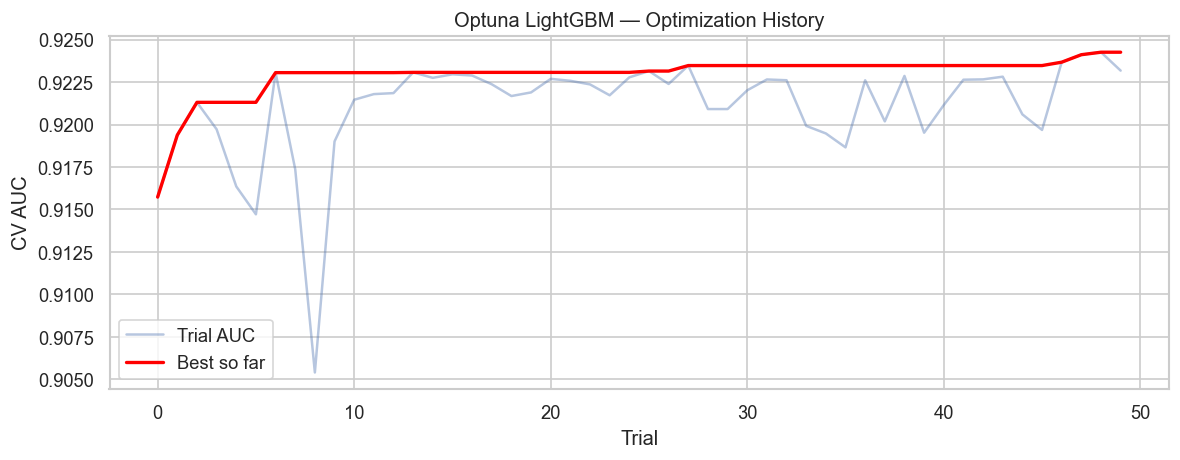

In [5]:
# Optuna optimization history
fig, ax = plt.subplots(figsize=(10, 4))
trials_df = lgbm_study.trials_dataframe()
ax.plot(trials_df['number'], trials_df['value'], alpha=0.4, color='#4C72B0', label='Trial AUC')
ax.plot(trials_df['number'],
        trials_df['value'].cummax(), color='red', linewidth=2, label='Best so far')
ax.set_title('Optuna LightGBM — Optimization History')
ax.set_xlabel('Trial')
ax.set_ylabel('CV AUC')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Tuned LightGBM — Full CV

In [6]:
LGBM_PARAMS = {
    'objective':        'binary',
    'metric':           'auc',
    'verbose':          -1,
    'random_state':     SEED,
    'n_jobs':           -1,
    'scale_pos_weight': spw,
    'n_estimators':     2000,  # more headroom with early stopping
    **lgbm_study.best_params
}

gkf = GroupKFold(n_splits=5)
oof_lgbm   = np.zeros(len(train))
test_lgbm  = np.zeros(len(test))
lgbm_models = []
lgbm_scores = []

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
    model = lgb.LGBMClassifier(**LGBM_PARAMS)
    model.fit(
        X.iloc[tr_idx], y.iloc[tr_idx],
        sample_weight=sample_weights[tr_idx],
        eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(200)
        ]
    )
    val_pred = model.predict_proba(X.iloc[val_idx])[:, 1]
    oof_lgbm[val_idx] = val_pred
    score = roc_auc_score(y.iloc[val_idx], val_pred)
    lgbm_scores.append(score)
    lgbm_models.append(model)
    test_lgbm += model.predict_proba(test[FEATURES])[:, 1] / 5
    print(f'Fold {fold+1} | best_iter={model.best_iteration_:>4} | AUC={score:.5f}')

lgbm_oof_auc = roc_auc_score(y, oof_lgbm)
print(f'\nTuned LightGBM OOF AUC: {lgbm_oof_auc:.5f}')
print(f'Mean CV: {np.mean(lgbm_scores):.5f} ± {np.std(lgbm_scores):.5f}')
print(f'Baseline OOF AUC was:   0.92130')
print(f'Improvement:            {lgbm_oof_auc - 0.92130:+.5f}')

[200]	valid_0's auc: 0.902966
[400]	valid_0's auc: 0.905133
[600]	valid_0's auc: 0.905882
Fold 1 | best_iter= 593 | AUC=0.90593
[200]	valid_0's auc: 0.931724
[400]	valid_0's auc: 0.932849
Fold 2 | best_iter= 446 | AUC=0.93303
[200]	valid_0's auc: 0.915116
Fold 3 | best_iter= 266 | AUC=0.91596
[200]	valid_0's auc: 0.939207
[400]	valid_0's auc: 0.940516
Fold 4 | best_iter= 441 | AUC=0.94058
[200]	valid_0's auc: 0.925743
[400]	valid_0's auc: 0.926091
Fold 5 | best_iter= 382 | AUC=0.92617

Tuned LightGBM OOF AUC: 0.92449
Mean CV: 0.92433 ± 0.01226
Baseline OOF AUC was:   0.92130
Improvement:            +0.00319


## 5. XGBoost — Second Model

In [8]:
def xgb_objective(trial):
    params = {
        'objective':        'binary:logistic',
        'eval_metric':      'auc',
        'verbosity':        0,
        'seed':             SEED,
        'n_jobs':           -1,
        'scale_pos_weight': spw,
        'n_estimators':     1000,
        'early_stopping_rounds': 30,  # moved to constructor in XGBoost >= 1.6
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 100),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'gamma':            trial.suggest_float('gamma', 1e-4, 5.0, log=True),
    }
    gkf = GroupKFold(n_splits=5)
    scores = []
    for tr_idx, val_idx in gkf.split(X, y, groups):
        model = xgb.XGBClassifier(**params)
        model.fit(
            X.iloc[tr_idx], y.iloc[tr_idx],
            sample_weight=sample_weights[tr_idx],
            eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],
            verbose=False
        )
        val_pred = model.predict_proba(X.iloc[val_idx])[:, 1]
        scores.append(roc_auc_score(y.iloc[val_idx], val_pred))
    return np.mean(scores)


print('Running Optuna study for XGBoost (30 trials)...')

xgb_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
xgb_study.optimize(xgb_objective, n_trials=30, show_progress_bar=True)

print(f'\nBest XGBoost AUC: {xgb_study.best_value:.5f}')
print(f'Best params:')
for k, v in xgb_study.best_params.items():
    print(f'  {k}: {v}')

Running Optuna study for XGBoost (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]


Best XGBoost AUC: 0.92413
Best params:
  learning_rate: 0.057793116710368374
  max_depth: 9
  min_child_weight: 34
  subsample: 0.7359923533324734
  colsample_bytree: 0.6311535438564047
  reg_alpha: 0.8833153434899682
  reg_lambda: 1.4164645789497639
  gamma: 0.15492228470056796


In [11]:
XGB_PARAMS = {
    'objective':             'binary:logistic',
    'eval_metric':           'auc',
    'verbosity':             0,
    'seed':                  SEED,
    'n_jobs':                -1,
    'scale_pos_weight':      spw,
    'n_estimators':          2000,
    'early_stopping_rounds': 50,  # must be in constructor, not fit()
    **xgb_study.best_params
}

gkf = GroupKFold(n_splits=5)
oof_xgb    = np.zeros(len(train))
test_xgb   = np.zeros(len(test))
xgb_models = []
xgb_scores = []

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
    model = xgb.XGBClassifier(**XGB_PARAMS)
    model.fit(
        X.iloc[tr_idx], y.iloc[tr_idx],
        sample_weight=sample_weights[tr_idx],
        eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],
        verbose=False
    )
    val_pred = model.predict_proba(X.iloc[val_idx])[:, 1]
    oof_xgb[val_idx] = val_pred
    score = roc_auc_score(y.iloc[val_idx], val_pred)
    xgb_scores.append(score)
    xgb_models.append(model)
    test_xgb += model.predict_proba(test[FEATURES])[:, 1] / 5
    print(f'Fold {fold+1} | best_iter={model.best_iteration:>4} | AUC={score:.5f}')

xgb_oof_auc = roc_auc_score(y, oof_xgb)
print(f'\nXGBoost OOF AUC:  {xgb_oof_auc:.5f}')
print(f'Mean CV: {np.mean(xgb_scores):.5f} ± {np.std(xgb_scores):.5f}')

Fold 1 | best_iter= 393 | AUC=0.90496
Fold 2 | best_iter= 334 | AUC=0.93185
Fold 3 | best_iter= 181 | AUC=0.91841
Fold 4 | best_iter= 282 | AUC=0.93990
Fold 5 | best_iter=  79 | AUC=0.92587

XGBoost OOF AUC:  0.92406
Mean CV: 0.92420 ± 0.01193


## 6. Model Correlation — Ensemble Diversity Check

OOF correlation (Pearson):  0.9927
OOF correlation (Spearman): 0.9836

⚠ High correlation — ensemble benefit will be limited


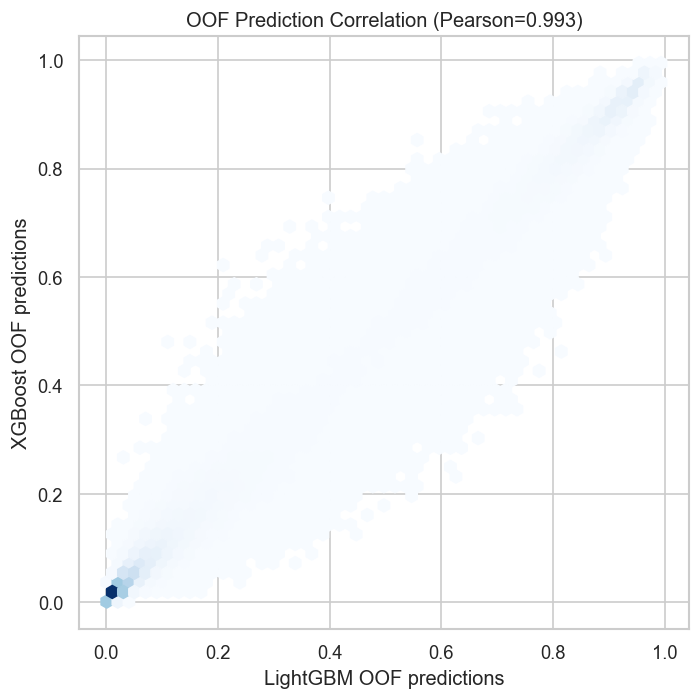

In [12]:
# Low correlation between OOF predictions = high ensemble benefit
# High correlation = models agree, ensemble won't help much
from scipy.stats import pearsonr, spearmanr

pearson_r, _ = pearsonr(oof_lgbm, oof_xgb)
spearman_r, _ = spearmanr(oof_lgbm, oof_xgb)

print(f'OOF correlation (Pearson):  {pearson_r:.4f}')
print(f'OOF correlation (Spearman): {spearman_r:.4f}')
print()
if pearson_r < 0.90:
    print('✓ Sufficient diversity — ensemble should improve over single model')
else:
    print('⚠ High correlation — ensemble benefit will be limited')

fig, ax = plt.subplots(figsize=(6, 6))
ax.hexbin(oof_lgbm, oof_xgb, gridsize=50, cmap='Blues', mincnt=1)
ax.set_xlabel('LightGBM OOF predictions')
ax.set_ylabel('XGBoost OOF predictions')
ax.set_title(f'OOF Prediction Correlation (Pearson={pearson_r:.3f})')
plt.tight_layout()
plt.show()

## 7. Weighted Ensemble — Find Optimal Blend

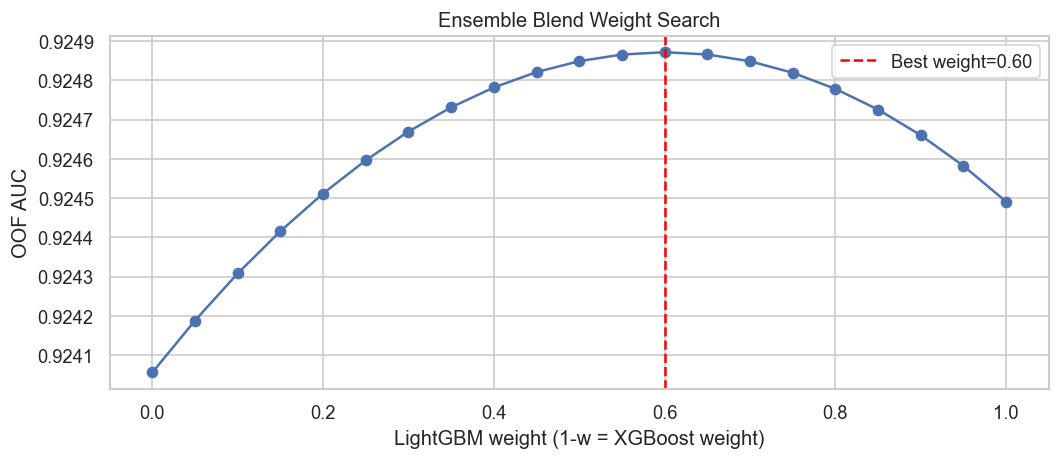

Best blend: 60% LGBM + 40% XGBoost
Ensemble OOF AUC:      0.92487
LGBM alone OOF AUC:    0.92449
XGBoost alone OOF AUC: 0.92406
Ensemble improvement:  +0.00038


In [13]:
# Grid search over blend weights using OOF predictions
# w * LGBM + (1-w) * XGBoost
best_auc   = 0
best_w     = 0.5
blend_results = []

for w in np.arange(0.0, 1.01, 0.05):
    blended = w * oof_lgbm + (1 - w) * oof_xgb
    auc = roc_auc_score(y, blended)
    blend_results.append({'lgbm_weight': w, 'auc': auc})
    if auc > best_auc:
        best_auc = auc
        best_w = w

blend_df = pd.DataFrame(blend_results)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(blend_df['lgbm_weight'], blend_df['auc'], marker='o', color='#4C72B0')
ax.axvline(best_w, color='red', linestyle='--', label=f'Best weight={best_w:.2f}')
ax.set_xlabel('LightGBM weight (1-w = XGBoost weight)')
ax.set_ylabel('OOF AUC')
ax.set_title('Ensemble Blend Weight Search')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Best blend: {best_w:.0%} LGBM + {1-best_w:.0%} XGBoost')
print(f'Ensemble OOF AUC:      {best_auc:.5f}')
print(f'LGBM alone OOF AUC:    {lgbm_oof_auc:.5f}')
print(f'XGBoost alone OOF AUC: {xgb_oof_auc:.5f}')
print(f'Ensemble improvement:  {best_auc - max(lgbm_oof_auc, xgb_oof_auc):+.5f}')

## 8. Generate Submissions

In [14]:
def make_submission(preds, filename):
    sub = pd.DataFrame({'id': test['id'], 'PitNextLap': preds})
    assert list(sub.columns) == list(sample_sub.columns)
    assert len(sub) == len(sample_sub)
    assert sub['PitNextLap'].between(0, 1).all()
    path = SUBM_DIR / filename
    sub.to_csv(path, index=False)
    print(f'Saved: {path} | mean={preds.mean():.4f} | range=[{preds.min():.4f}, {preds.max():.4f}]')
    return sub

# Tuned LGBM only
sub_lgbm = make_submission(test_lgbm, 'tuned_lgbm.csv')

# XGBoost only
sub_xgb = make_submission(test_xgb, 'tuned_xgb.csv')

# Ensemble
test_ensemble = best_w * test_lgbm + (1 - best_w) * test_xgb
sub_ensemble = make_submission(test_ensemble, 'ensemble_lgbm_xgb.csv')

Saved: submissions/tuned_lgbm.csv | mean=0.3042 | range=[0.0019, 0.9920]
Saved: submissions/tuned_xgb.csv | mean=0.3077 | range=[0.0040, 0.9926]
Saved: submissions/ensemble_lgbm_xgb.csv | mean=0.3056 | range=[0.0029, 0.9923]
